### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

### Load The Dataset

In [3]:
df = pd.read_csv("CC GENERAL.csv")

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
#Dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8950
Number of columns: 18


### Understanding The Dataset

In [5]:
#Column names
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [6]:
#Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [7]:
#Statistical Summary
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [8]:
#Check Missing Values
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [9]:
#check duplicate values
df.duplicated().sum()

np.int64(0)

### Data Cleaning

In [10]:
#Removing customer_ID
df = df.drop("CUST_ID", axis=1)

In [11]:
#Handle missing values
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(
    df["CREDIT_LIMIT"].median()
)

df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(
    df["MINIMUM_PAYMENTS"].median()
)

In [12]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

### Create The Target Variable

In [13]:
#PRC_FULL_PAYMENT >= 0.5  → Full Payer
#PRC_FULL_PAYMENT < 0.5   → Partial/Non-Full Payer

In [14]:
#Creating the target variable
df["Payment_Status"] = np.where(
    df["PRC_FULL_PAYMENT"] >= 0.5,
    "Full Payer",
    "Partial/Non-Full Payer"
)

In [15]:
df["Payment_Status"].value_counts()

Payment_Status
Partial/Non-Full Payer    7674
Full Payer                1276
Name: count, dtype: int64

### EDA - Eploratory Data Analysis 

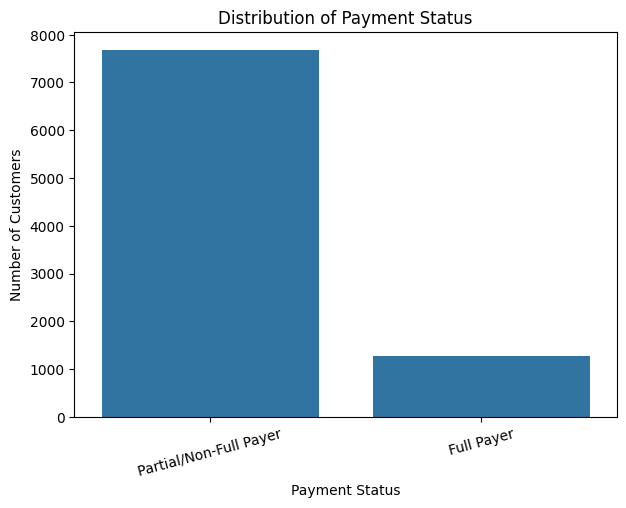

In [16]:
#Target distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    x="Payment_Status",
    data=df
)

plt.title("Distribution of Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

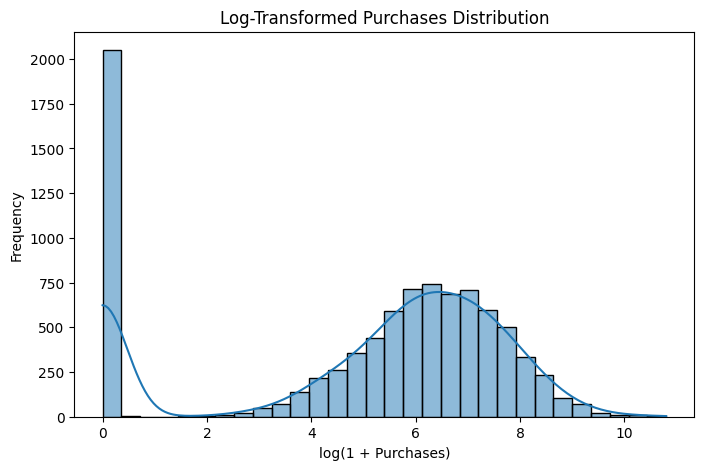

In [17]:
#Distribution of Purchases
df["PURCHASES_LOG"] = np.log1p(df["PURCHASES"])

plt.figure(figsize=(8, 5))

sns.histplot(
    df["PURCHASES_LOG"],
    bins=30,
    kde=True
)

plt.title("Log-Transformed Purchases Distribution")
plt.xlabel("log(1 + Purchases)")
plt.ylabel("Frequency")

plt.show()

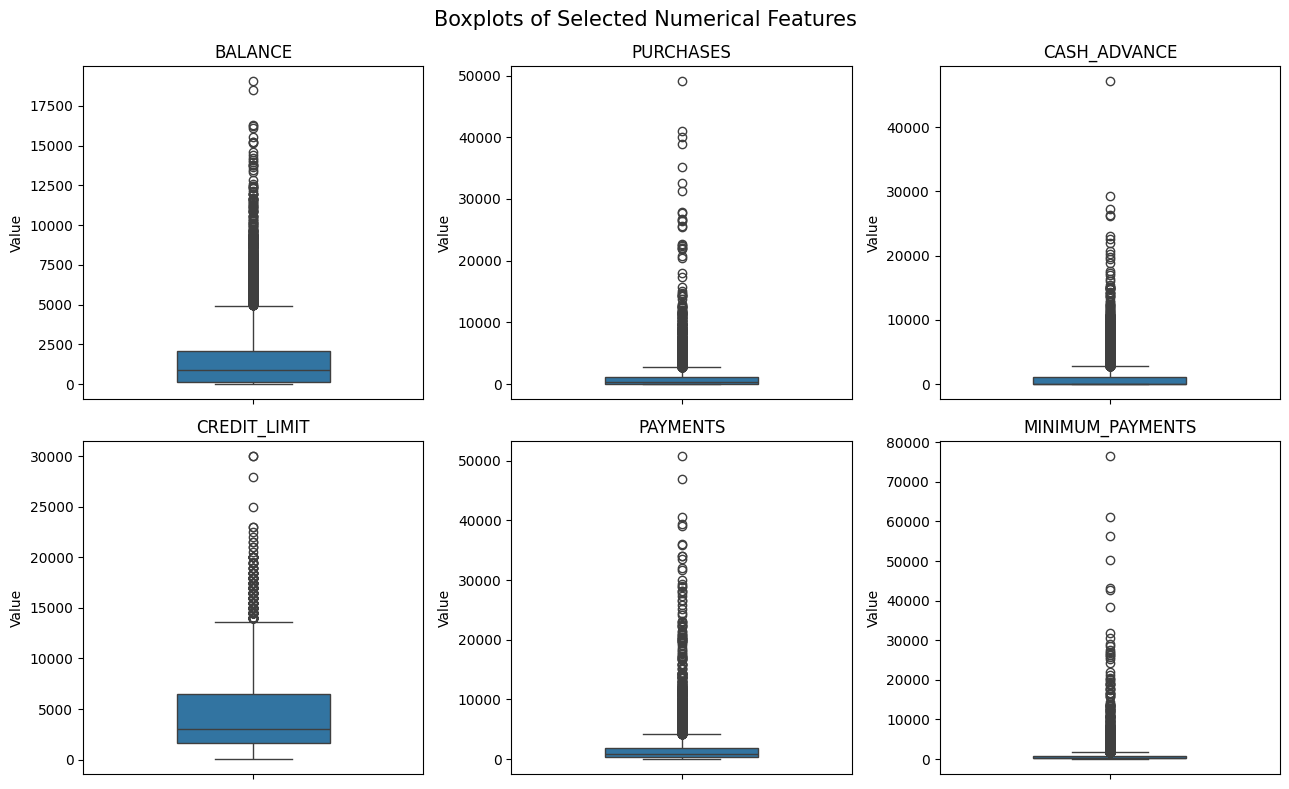

In [18]:
#Box plots
selected_features = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, feature in enumerate(selected_features):

    sns.boxplot(
        y=df[feature],
        ax=axes[i],
        showfliers=True,
        width=0.45
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")

plt.suptitle(
    "Boxplots of Selected Numerical Features",
    fontsize=15
)

plt.tight_layout()
plt.show()

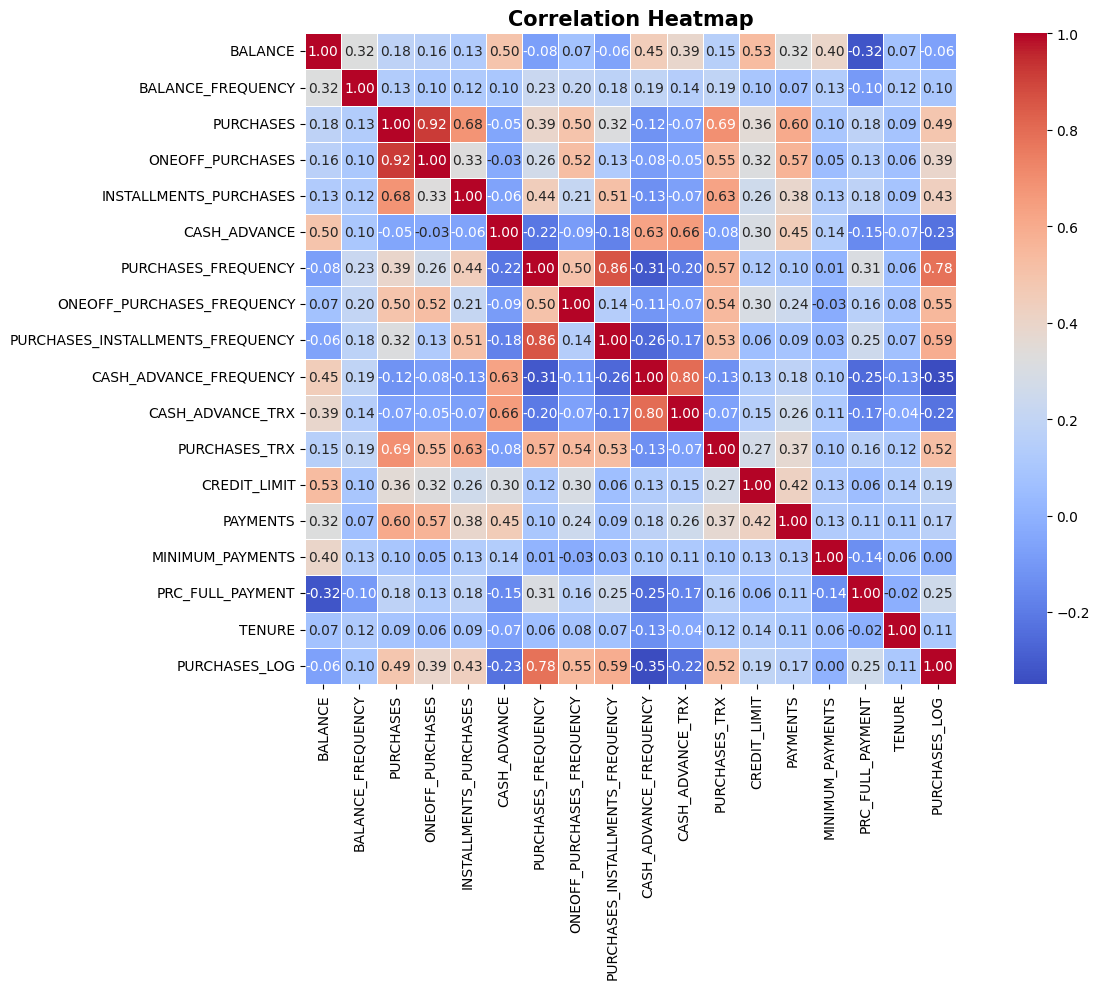

In [19]:
### Correlation Heatmap
plt.figure(figsize=(14, 10))

corr = df.drop("Payment_Status", axis=1).corr()

sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Feature Selection

In [20]:
X = df.drop(
    ["Payment_Status", "PRC_FULL_PAYMENT", "PURCHASES_LOG"],
    axis=1
)

y = df["Payment_Status"]

In [21]:
print("Number of features:", X.shape[1])
print("Features:")
print(X.columns.tolist())

Number of features: 16
Features:
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'TENURE']


In [22]:
### Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
### Feature Scaling 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Logistic Regression Model

In [24]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [25]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
y_pred_lr = logistic_model.predict(X_test_scaled)

### Evalauate Logistic Regression Model

In [27]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:",
      lr_accuracy)

Logistic Regression Accuracy: 0.8905027932960894


In [28]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

                        precision    recall  f1-score   support

            Full Payer       0.67      0.45      0.54       255
Partial/Non-Full Payer       0.91      0.96      0.94      1535

              accuracy                           0.89      1790
             macro avg       0.79      0.71      0.74      1790
          weighted avg       0.88      0.89      0.88      1790



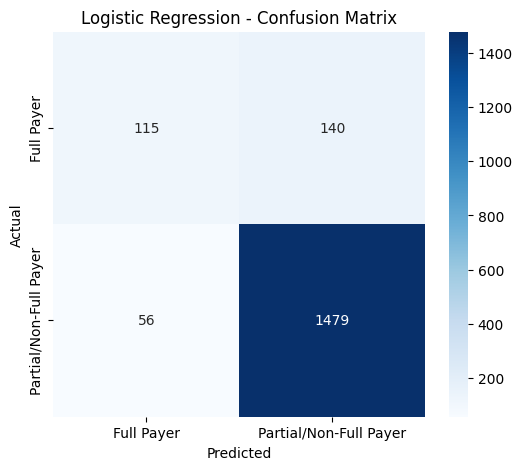

In [29]:
#Confusion matrix
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Full Payer", "Partial/Non-Full Payer"],
    yticklabels=["Full Payer", "Partial/Non-Full Payer"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

### KNN - Test Different K Values

In [30]:
k_values = range(1, 21)

knn_accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    knn_accuracies.append(accuracy)

### Plot Accuracy Vs K 

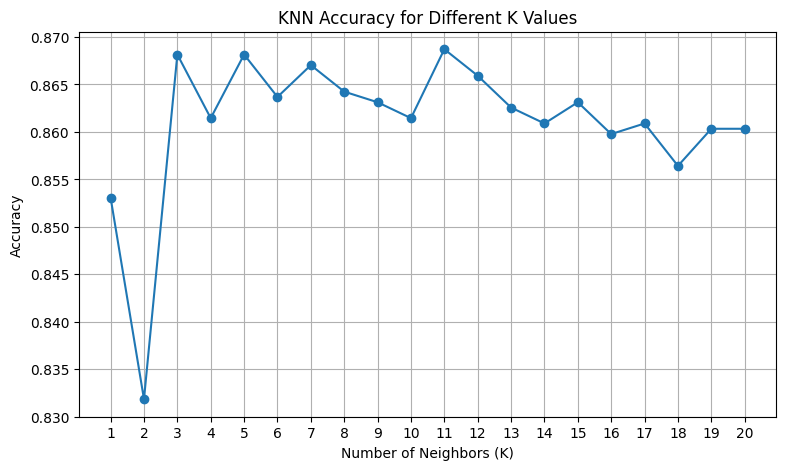

In [31]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    knn_accuracies,
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

### Find Best K

In [32]:
best_k = k_values[
    np.argmax(knn_accuracies)
]

best_accuracy = max(knn_accuracies)

print("Best K:", best_k)
print("Best KNN Accuracy:", best_accuracy)

Best K: 11
Best KNN Accuracy: 0.8687150837988827


### Train Final KNN

In [33]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_scaled
)

### Evaluate KNN 

In [34]:
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:",
      knn_accuracy)

KNN Accuracy: 0.8687150837988827


In [35]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

                        precision    recall  f1-score   support

            Full Payer       0.55      0.43      0.48       255
Partial/Non-Full Payer       0.91      0.94      0.92      1535

              accuracy                           0.87      1790
             macro avg       0.73      0.69      0.70      1790
          weighted avg       0.86      0.87      0.86      1790



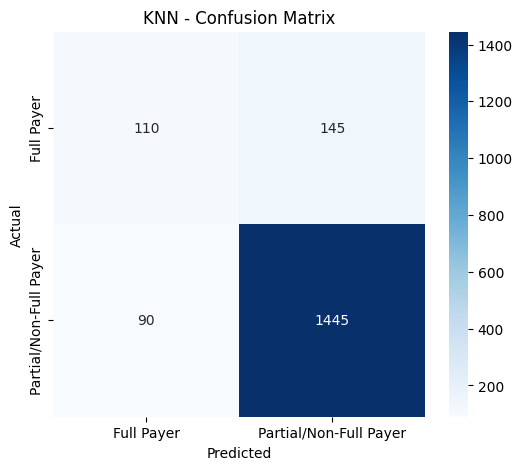

In [36]:
#Confusion Matrix
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Full Payer", "Partial/Non-Full Payer"],
    yticklabels=["Full Payer", "Partial/Non-Full Payer"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")

plt.show()

### Compare Logistic Regression And KNN 

In [37]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn)
    ],
    
    "Precision": [
        precision_score(
            y_test,
            y_pred_lr,
            pos_label="Full Payer"
        ),
        precision_score(
            y_test,
            y_pred_knn,
            pos_label="Full Payer"
        )
    ],
    
    "Recall": [
        recall_score(
            y_test,
            y_pred_lr,
            pos_label="Full Payer"
        ),
        recall_score(
            y_test,
            y_pred_knn,
            pos_label="Full Payer"
        )
    ],
    
    "F1 Score": [
        f1_score(
            y_test,
            y_pred_lr,
            pos_label="Full Payer"
        ),
        f1_score(
            y_test,
            y_pred_knn,
            pos_label="Full Payer"
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.890503,0.672515,0.450980,0.539906
1,KNN,0.868715,0.550000,0.431373,0.483516


### Model Comparison PLot

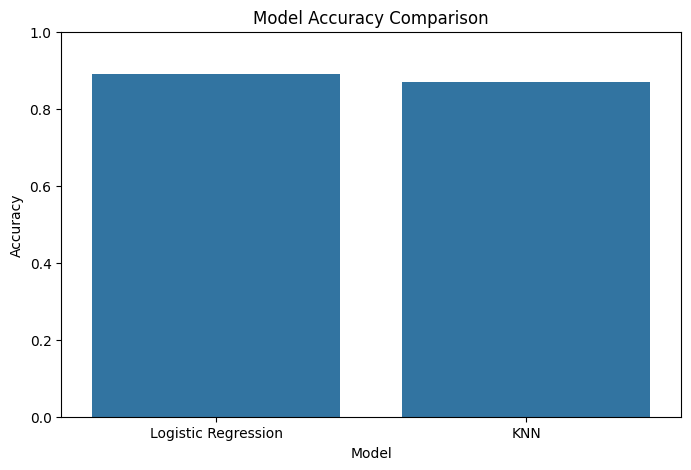

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()